# Walrasian Tâtonnement — Setup

Modular implementation of the tâtonnement algorithm for the social planner's problem.

**Two-loop architecture:**
- **Outer loop**: prices $(p, w, r, \beta)$, production, households, infrastructure.
- **Inner loop**: flows $(Q^s_{ij}, q^s_{ij}, \hat{Q}_{nn'}, \gamma_{nn'})$ at fixed outer prices.

This notebook contains only the **setup**: data structures, parameters, block functions. The loops will be implemented in a second step.

In [344]:
import numpy as np
import heapq
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional, Callable
from abc import ABC, abstractmethod
from collections import deque
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 1. Data structures

We define three dataclasses:
- `Network`: topology of the transport network (nodes, edges, infrastructure).
- `ModelParams`: economic parameters (Cobb-Douglas, endowments, transport).
- `State`: current state (prices, quantities, flows) — updated at each iteration. 

In [345]:
""" Useful tools """
def _logsumexp(x):
    x = np.asarray(x).ravel()
    m = np.max(x)
    if not np.isfinite(m):
        return m
    return m + np.log(np.sum(np.exp(x - m)))

In [346]:
class Functions(ABC):
    @abstractmethod
    def __call__(self, *args, **kwargs):
        pass

    @abstractmethod
    def gradient(self, *args, **kwargs):
        pass


class ProductionFunction(Functions):
    @abstractmethod
    def invert(*args, **kwargs):
        """Given prices p, compute the inputs H, L, Q_inp."""
        pass


class UtilityFunction(Functions):
    @abstractmethod
    def invert(*args, **kwargs):
        """Given prices, compute the consumption c and land l."""
        pass

class TauLink(Functions):
    pass

class TimeLink(Functions):
    pass

**Examples of functions**

In [347]:
class CobbDouglasUtility(UtilityFunction):
    """
    U^s(c, l) = sum_k alpha_c[s,k] * log(c_k) + alpha_l[s] * log(l).
    alpha_c: (S, S) — alpha_c[s, k] = weight of good k in sector-s utility.
    alpha_l: (S,)
    """
    def __init__(self, alpha_c: np.ndarray, alpha_l: np.ndarray):
        self.alpha_c = np.asarray(alpha_c, dtype=float)
        self.alpha_l = np.asarray(alpha_l, dtype=float)

    def __call__(self, c, l, s, i=None, j=None):
        c = np.asarray(c)
        return float(np.sum(self.alpha_c[s] * np.log(c)) + self.alpha_l[s] * np.log(l))

    def gradient(self, c, l, s, i=None, j=None):
        c = np.asarray(c)
        return self.alpha_c[s] / c, self.alpha_l[s] / l   # (dU/dc, dU/dl)

    def invert(self, p_i, r_i, s, i=None, j=None):
        c = self.alpha_c[s] / p_i           # shape (S,)
        l = self.alpha_l[s] / r_i
        return c, l
    

class CobbDouglasProduction(ProductionFunction):
    """
    Y = A * H^aH * L^aL * prod_k Q_k^{aQ_k}, with sum(a) < 1.
    A:     (S, J)
    aH:    (S,)
    aL:    (S,)
    aQ:    (S, S)  — aQ[s, k] = elasticity of good k in sector-s production.
    """
    def __init__(self, A: np.ndarray, aH: np.ndarray, aL: np.ndarray, aQ: np.ndarray):
        self.A  = np.asarray(A,  dtype=float)
        self.aH = np.asarray(aH, dtype=float)
        self.aL = np.asarray(aL, dtype=float)
        self.aQ = np.asarray(aQ, dtype=float)
        assert np.all(self.aH + self.aL + self.aQ.sum(axis=1) < 1), \
            "Cobb-Douglas requires decreasing returns (sum of elasticities < 1)."

    def __call__(self, H, L, Q_inp, s, j):
        Q_inp = np.asarray(Q_inp, dtype=float)
        # 0**0 = 1 by convention
        prodQ = np.prod(np.where(self.aQ[s] > 0, Q_inp ** self.aQ[s], 1.0))
        return float(self.A[s, j] * H ** self.aH[s] * L ** self.aL[s] * prodQ)

    def gradient(self, H, L, Q_inp, s, j, var=None):
        Y = self(H, L, Q_inp, s, j)
        if var == 'H':     return self.aH[s] * Y / H
        if var == 'L':     return self.aL[s] * Y / L
        if var == 'Q':
            Q_inp = np.asarray(Q_inp, dtype=float)
            return np.where(Q_inp > 0, self.aQ[s] * Y / np.where(Q_inp > 0, Q_inp, 1.0), 0.0)
        # default: return all
        return self.aH[s] * Y / H, self.aL[s] * Y / L, self.aQ[s] * Y / Q_inp

    def invert(self, p_sj, p_vec, w_s, r_j, s, j):
        aH, aL, aQ = self.aH[s], self.aL[s], self.aQ[s]
        S_sum = aH + aL + aQ.sum()

        log_Y  = np.log(self.A[s, j]) + S_sum * np.log(p_sj)
        log_Y += aH * np.log(aH / w_s) + aL * np.log(aL / r_j)
        # 0 * log(0) = 0
        mask = aQ > 0
        log_Y += np.sum(aQ[mask] * np.log(aQ[mask] / p_vec[mask]))
        log_Y /= (1.0 - S_sum)

        Y = np.exp(log_Y)
        H = aH * Y * p_sj / w_s
        L = aL * Y * p_sj / r_j
        Q_inp = np.zeros_like(p_vec)
        Q_inp[mask] = aQ[mask] * Y * p_sj / p_vec[mask]
        return Y, H, L, Q_inp

class IcebergTau(TauLink):
    """
    tau^s_{nn'} = exp(-delta_s * Qhat_{nn'} / I_{nn'}).
    delta: scalar or shape (S,)
    """
    def __init__(self, delta):
        self.delta = np.atleast_1d(np.asarray(delta, dtype=float))  # (S,) or (1,)

    def __call__(self, Q_hat, I):
        ratio = Q_hat / I                              # (n_edges,)
        return np.exp(-self.delta[:, None] * ratio[None, :])   # (S, n_edges)

    def gradient(self, Q_hat, I, var):
        tau = self(Q_hat, I)                           # (S, n_edges)
        if var == 'Q':
            return -self.delta[:, None] / I[None, :] * tau
        if var == 'I':
            return self.delta[:, None] * Q_hat[None, :] / I[None, :] ** 2 * tau
        raise ValueError(f"unknown var={var}")
    

class BPRTime(TimeLink):
    """
    T_{nn'} = T0 * (1 + a * (Qhat / I)^b).
    T0:   shape (n_edges,)
    a, b: scalars (typically a=0.15, b=4).
    """
    def __init__(self, T0, a: float = 0.15, b: float = 4.0):
        self.T0 = np.asarray(T0, dtype=float)          # (n_edges,)
        self.a  = float(a)
        self.b  = float(b)

    def __call__(self, Q_hat, I):
        return self.T0 * (1.0 + self.a * (Q_hat / I) ** self.b)

    def gradient(self, Q_hat, I, var):
        if var == 'Q':
            return self.T0 * self.a * self.b * Q_hat ** (self.b - 1) / I ** self.b
        if var == 'I':
            return -self.T0 * self.a * self.b * Q_hat ** self.b / I ** (self.b + 1)
        raise ValueError(f"unknown var={var}")

In [348]:
@dataclass
class Network:
    """Transport network: nodes and edges."""
    n_nodes: int
    edges: List[Tuple[int, int]]                 # list [(n, n'), ...]
    kappa: np.ndarray                            # unit infrastructure cost per edge, shape (n_edges,)
    I_min: np.ndarray                            # lower bounds I_nn',  shape (n_edges,)
    I_max: np.ndarray                            # upper bounds I_nn',  shape (n_edges,)
    zone_to_node: np.ndarray                     # mapping zone -> node, shape (n_zones,)

    def __post_init__(self):
        self.n_edges = len(self.edges)
        # Adjacency: for each node n, list of (n', edge_idx)
        self.adj_out: List[List[Tuple[int, int]]] = [[] for _ in range(self.n_nodes)]
        self.adj_in:  List[List[Tuple[int, int]]] = [[] for _ in range(self.n_nodes)]
        for e, (n, np_) in enumerate(self.edges):
            self.adj_out[n].append((np_, e))
            self.adj_in[np_].append((n, e))

In [349]:
@dataclass
class ModelParams:
    """Economic model parameters."""
    # ---- Sizes ----
    n_zones: int                                  # |I|
    n_sectors: int                                # |S|

    # ---- Production ----
    production_function: ProductionFunction  # function to compute output Y given inputs H, L, Q_inp

    # ---- Households ----
    utility_function: UtilityFunction  # function to utility U given consumption c and land l

    # ---- Endowments ----
    L_bar: np.ndarray                             # land per zone, shape (J,)
    H_bar: float                                  # total time per capita
    q_bar: float                                  # total population
    K: float                                      # infrastructure budget

    # ---- Iceberg costs ----
    tau_link: TauLink  # per-edge iceberg cost, shape (n_edges,) given infrastructure I_infra and flow Qhat

    # ---- Transportation time ----
    t_link: TimeLink  # per-edge transport time, shape (n_edges,) given infrastructure I_infra and flow Qhat

    # ---- Transport ----
    d_w: float                                    # working days (time -> cost conversion)
    phi: np.ndarray                               # weight of good s per unit volume, shape (S,)

    # ---- Logit ----
    sigma: np.ndarray                             # OD logit,     shape (S,)
    sigma_tilde: float                            # sector logit
    
    #---- Network ----
    network: Network

In [350]:
@dataclass
class ModelState:
    """Current state: prices, quantities, flows."""
    # ---- Prices (outer loop) ----
    p: np.ndarray                                 # goods prices,    shape (S, J)
    w: np.ndarray                                 # wages,           shape (S,)
    r: np.ndarray                                 # land rents,      shape (J,)
    beta: float                                   # infrastructure price
    gamma: np.ndarray                             # congestion,      shape (n_edges,)
   

    # ---- Production / households ----
    Y: np.ndarray                                 # output,          shape (S, J)
    H_prod: np.ndarray                            # labor demand,    shape (S, J)
    L_prod: np.ndarray                            # land demand,     shape (S, J)
    Q_inter: np.ndarray                           # intersectoral inputs, shape (S, S, J)

    c: np.ndarray                                 # consumption, shape (S, S, I, J)
    l_res: np.ndarray                             # residential land, shape (S, I, J)

    
    # ---- Flows (inner loop) ----
    Q_ship: np.ndarray                            # shipped volumes Q^s_{ij}, shape (S, I, J)
    Q_tilde: np.ndarray                           # received volumes,         shape (S, I, J)
    tau_eff: np.ndarray                           # effective retention factor on route, shape (S, I, J)
    active: np.ndarray                            # active OD arcs mask, shape (S, I, J)

    q_pop: np.ndarray                             # population q^s_{ij}, shape (S, I, J)
    q_bar_s: np.ndarray                           # population by sector, shape (S,)

    Q_hat: np.ndarray                             # total flow per edge, shape (n_edges,)
    q_hat_s: np.ndarray                           # commuters by sector,   shape (S, n_edges)
    Q_hat_s_goods: np.ndarray                     # goods by sector,       shape (S, n_edges)
    Q_hat_s_price_goods: np.ndarray               # price-weighted goods,  shape (S, n_edges) = sum_s nu[s,i,j] * Q_goods_link[s,i,j]

    # ---- Infrastructure ----
    I_infra: np.ndarray                           # infrastructure levels, shape (n_edges,)
    gamma_I: np.ndarray                           # infra gradient,  shape (n_edges,)

## 2. Algorithm hyperparameters

The update step sizes for prices (outer) and flows (inner) are kept separate.

In [351]:
@dataclass
class AlgoParams:
    # Outer loop
    T_outer: int = 200
    eta_p: float = 0.05
    eta_w: float = 0.05
    eta_r: float = 0.05
    eta_beta: float = 0.01
    eta_I: float = 0.01

    # Inner loop (flows)
    T_inner: int = 50
    alpha_Q: float = 0.2                          # volume update step
    alpha_Qhat: float = 0.3                       # MSA damping on Qhat
    eta_gamma: float = 0.01

    # Tolerances
    tol_outer: float = 1e-4
    tol_inner: float = 1e-4

    # Logging
    verbose: bool = True
    log_every: int = 10

In [352]:
class ConvergenceLoggerOuter:
    def __init__(self):
        self.history = {
            'excess_demand': [],
            'price_changes': []
        }

    def log(self, excess_demand, price_changes):
        self.history['excess_demand'].append(excess_demand)
        self.history['price_changes'].append(price_changes)


class ConvergenceLoggerInner:
    def __init__(self):
        self.history = {
            'flow_changes': [],
            'congestion_changes': []
        }

    def log(self, flow_changes, congestion_changes):
        self.history['flow_changes'].append(flow_changes)
        self.history['congestion_changes'].append(congestion_changes)

class ConvergenceVisualization:
    pass

## 3. Household block 

In [353]:
class HouseholdBlock:
    def solve(self, state: ModelState, params: ModelParams):
        for s in range(params.n_sectors):
            for i in range(params.n_zones):
                p_i = state.p[:, i]
                r_i = state.r[i]
                for j in range(params.n_zones):
                    c, l = params.utility_function.invert(p_i, r_i, s=s, i=i, j=j)
                    state.c[:, s, i, j] = c
                    state.l_res[s, i, j] = l

## 4. Production block 

In [354]:
class ProductionBlock:
    def solve(self, state: ModelState, params: ModelParams):
        for s in range(params.n_sectors):
            for j in range(params.n_zones):
                p_sj = state.p[s, j]
                p_j  = state.p[:, j]
                w_s  = state.w[s]
                r_j  = state.r[j]
                Y, H, L, Q_inp = params.production_function.invert(
                    p_sj, p_j, w_s, r_j, s=s, j=j
                )
                state.Y[s, j]            = Y
                state.H_prod[s, j]       = H
                state.L_prod[s, j]       = L
                state.Q_inter[s, :, j]   = Q_inp     # Q_inter[s, k, j] = good k used by sector s

## 5. Transport Block



In [355]:
class TransportBlock:
    def __init__(self):
        self.commuters = CommuterSubBlock()
        self.goods = GoodsSubBlock()
        self.flow_aggregator = FlowAggregator()

    def solve(self, state: ModelState, params: ModelParams):
        self.commuters.solve(state, params)
        self.goods.solve(state, params)
        self.flow_aggregator.update_qhat(state, params)
        self.flow_aggregator.update_gamma(state, params)

class CommuterSubBlock:
    def _dijkstra(self, net, src, weights):
        n = net.n_nodes
        dist      = np.full(n, np.inf)
        pred_node = np.full(n, -1, dtype=int)
        pred_edge = np.full(n, -1, dtype=int)
        dist[src] = 0.0
        pq = [(0.0, src)]
        while pq:
            d, u = heapq.heappop(pq)
            if d > dist[u]:
                continue
            for v, e in net.adj_out[u]:
                nd = d + weights[e]
                if nd < dist[v]:
                    dist[v] = nd
                    pred_node[v] = u
                    pred_edge[v] = e
                    heapq.heappush(pq, (nd, v))
        return dist, pred_node, pred_edge

    def shortest_paths(self, state, params):
        net = params.network
        S, I = params.n_sectors, params.n_zones
        T = params.t_link(state.Q_hat, state.I_infra)        # (n_edges,)

        self.dist      = np.full((S, I, I), np.inf)
        self.pred_node = np.full((S, I, net.n_nodes), -1, dtype=int)
        self.pred_edge = np.full((S, I, net.n_nodes), -1, dtype=int)

        for s in range(S):
            w_edge = state.w[s] * params.d_w * T + state.gamma
            for i in range(I):
                d, pn, pe = self._dijkstra(net, net.zone_to_node[i], w_edge)
                self.pred_node[s, i] = pn
                self.pred_edge[s, i] = pe
                for j in range(I):
                    self.dist[s, i, j] = d[net.zone_to_node[j]]

    def compute_allocation(self, state, params):
        S, I = params.n_sectors, params.n_zones
        V = np.zeros((S, I, I))
        for s in range(S):
            for i in range(I):
                p_i, r_i = state.p[:, i], state.r[i]
                for j in range(I):
                    c   = state.c[:, s, i, j]
                    lij = state.l_res[s, i, j]
                    U   = params.utility_function(c, lij, s=s, i=i, j=j)
                    V[s, i, j] = U - r_i * lij - p_i @ c - self.dist[s, i, j]

        A = np.array([
            state.w[s] * params.H_bar
            + params.sigma_tilde * _logsumexp(V[s] / params.sigma[s])
            for s in range(S)
        ])
        log_norm_s = _logsumexp(A / params.sigma_tilde)
        state.q_bar_s = params.q_bar * np.exp(A / params.sigma_tilde - log_norm_s)

        for s in range(S):
            ln = _logsumexp(V[s] / params.sigma[s])
            state.q_pop[s] = state.q_bar_s[s] * np.exp(V[s] / params.sigma[s] - ln)

        self.V = V

    def accumulate_flows(self, state, params):
        net = params.network
        S, I = params.n_sectors, params.n_zones
        new_q = np.zeros((S, net.n_edges))
        for s in range(S):
            for i in range(I):
                src = net.zone_to_node[i]
                for j in range(I):
                    if i == j:
                        continue
                    vol = state.q_pop[s, i, j]
                    if vol <= 0:
                        continue
                    cur = net.zone_to_node[j]
                    while cur != src and cur != -1:
                        e = self.pred_edge[s, i, cur]
                        if e < 0:
                            break
                        new_q[s, e] += vol
                        cur = self.pred_node[s, i, cur]
        # damping
        a = params.alpha_Qhat
        state.q_hat_s = (1 - a) * state.q_hat_s + a * new_q

    def solve(self, state, params):
        self.shortest_paths(state, params)
        self.compute_allocation(state, params)
        self.accumulate_flows(state, params)


class GoodsSubBlock:
    def backward_spfa(self, state, params):
        net = params.network
        S, I = params.n_sectors, params.n_zones
        # tau per sector and edge: shape (S, n_edges). If tau_link returns (n_edges,), broadcast.
        tau = params.tau_link(state.Q_hat, state.I_infra)
        tau = np.asarray(tau)
        if tau.ndim == 1:
            tau = np.broadcast_to(tau, (S, net.n_edges))

        self.v         = np.full((S, I, net.n_nodes), -np.inf)
        self.next_node = np.full((S, I, net.n_nodes), -1, dtype=int)
        self.next_edge = np.full((S, I, net.n_nodes), -1, dtype=int)

        for s in range(S):
            for j in range(I):
                v        = self.v[s, j]
                nxt_node = self.next_node[s, j]
                nxt_edge = self.next_edge[s, j]
                jn       = net.zone_to_node[j]
                v[jn]    = state.p[s, j]

                in_queue = np.zeros(net.n_nodes, dtype=bool)
                queue    = deque([jn])
                in_queue[jn] = True

                while queue:
                    np_ = queue.popleft()
                    in_queue[np_] = False
                    # iterate over predecessors n with edge n -> np_
                    for n, e in net.adj_in[np_]:
                        cand = tau[s, e] * v[np_] - state.gamma[e] * params.phi[s] / params.d_w
                        if cand > v[n]:
                            v[n]        = cand
                            nxt_node[n] = np_
                            nxt_edge[n] = e
                            if not in_queue[n]:
                                queue.append(n)
                                in_queue[n] = True

    def compute_surplus(self, state, params):
        net = params.network
        S, I = params.n_sectors, params.n_zones
        tau = params.tau_link(state.Q_hat, state.I_infra)
        tau = np.asarray(tau)
        if tau.ndim == 1:
            tau = np.broadcast_to(tau, (S, net.n_edges))

        self.nu      = np.full((S, I, I), -np.inf)            # nu[s,i,j] = v at origin i, dest j
        state.active = np.zeros((S, I, I), dtype=bool)
        state.tau_eff = np.zeros((S, I, I))

        for s in range(S):
            for j in range(I):
                for i in range(I):
                    if i == j:
                        continue
                    src = net.zone_to_node[i]
                    self.nu[s, i, j] = self.v[s, j, src]
                    if self.v[s, j, src] >= state.p[s, i]:
                        state.active[s, i, j] = True
                        # walk next pointers, accumulate tau product
                        t_eff = 1.0
                        cur = src
                        dst = net.zone_to_node[j]
                        while cur != dst and cur != -1:
                            e = self.next_edge[s, j, cur]
                            if e < 0:
                                break
                            t_eff *= tau[s, e]
                            cur = self.next_node[s, j, cur]
                        state.tau_eff[s, i, j] = t_eff

    def update_volumes(self, state, params):
        S, I = params.n_sectors, params.n_zones
        a = params.alpha_Q
        for s in range(S):
            for i in range(I):
                for j in range(I):
                    if i == j:
                        continue
                    # update gradient regardless of active flag
                    grad = self.nu[s, i, j] - state.p[s, i]
                    new_Q = state.Q_ship[s, i, j] + a * grad
                    state.Q_ship[s, i, j] = max(0.0, new_Q)

        # Q_tilde update with damping
        Q_tilde_new = state.Q_ship * state.tau_eff
        state.Q_tilde = (1 - a) * state.Q_tilde + a * Q_tilde_new

    def accumulate_flows(self, state, params):
        net = params.network
        S, I = params.n_sectors, params.n_zones

        new_goods       = np.zeros((S, net.n_edges))
        new_goods_price = np.zeros((S, net.n_edges))
        tau = params.tau_link(state.Q_hat, state.I_infra)
        tau = np.asarray(tau)
        if tau.ndim == 1:
            tau = np.broadcast_to(tau, (S, net.n_edges))

        for s in range(S):
            for i in range(I):
                for j in range(I):
                    if i == j or not state.active[s, i, j]:
                        continue
                    vol = state.Q_ship[s, i, j]
                    if vol <= 0:
                        continue
                    src = net.zone_to_node[i]
                    dst = net.zone_to_node[j]
                    cur = src
                    while cur != dst and cur != -1:
                        e   = self.next_edge[s, j, cur]
                        nxt = self.next_node[s, j, cur]
                        if e < 0:
                            break
                        new_goods[s, e]       += vol
                        # nu^s_j(n_{k+1}) = v[s, j, nxt]
                        new_goods_price[s, e] += self.v[s, j, nxt] * vol
                        vol *= tau[s, e]      # iceberg attenuation along the route
                        cur = nxt

        a = params.alpha_Qhat
        state.Q_hat_s_goods       = (1 - a) * state.Q_hat_s_goods       + a * new_goods
        state.Q_hat_s_price_goods = (1 - a) * state.Q_hat_s_price_goods + a * new_goods_price

    def solve(self, state, params):
        self.backward_spfa(state, params)
        self.compute_surplus(state, params)
        self.update_volumes(state, params)
        self.accumulate_flows(state, params)

class FlowAggregator:
    def update_qhat(self, state, params):
        # Qhat_{nn'} = sum_s (phi_s/d_w) Q^{s,goods}_{nn'} + sum_s q^s_{nn'}
        weighted_goods   = (params.phi[:, None] / params.d_w) * state.Q_hat_s_goods
        state.Q_hat = weighted_goods.sum(axis=0) + state.q_hat_s.sum(axis=0)

    def update_gamma(self, state, params):
        # dT/dQ and dtau/dQ at the new Q_hat
        dT_dQ   = np.asarray(params.t_link.gradient(state.Q_hat, state.I_infra, var='Q'))
        dtau_dQ = np.asarray(params.tau_link.gradient(state.Q_hat, state.I_infra, var='Q'))
        if dtau_dQ.ndim == 1:
            dtau_dQ = np.broadcast_to(dtau_dQ, state.Q_hat_s_goods.shape)

        commute_term = dT_dQ * (params.d_w * (state.w[:, None] * state.q_hat_s).sum(axis=0))
        goods_term   = (dtau_dQ * state.Q_hat_s_price_goods).sum(axis=0)

        gamma_new = commute_term - goods_term
        # damped, projected on non-negatives
        state.gamma = np.maximum(
            0.0,
            state.gamma + params.eta_gamma * (gamma_new - state.gamma)
        )



## 6. Infrastructure Block

In [356]:
class InfrastructureBlock:
    def update(self, state, params):
        net = params.network
        dT_dI   = np.asarray(params.t_link.gradient(state.Q_hat, state.I_infra, var='I'))
        dtau_dI = np.asarray(params.tau_link.gradient(state.Q_hat, state.I_infra, var='I'))
        if dtau_dI.ndim == 1:
            dtau_dI = np.broadcast_to(dtau_dI, state.Q_hat_s_price_goods.shape)

        violation = max(0.0, (net.kappa * state.I_infra).sum() - params.K)
        beta_eff  = 10 * violation     # smooth penalty, replaces state.beta
        I_new = state.I_infra + params.eta_I * (state.gamma_I - beta_eff * net.kappa)
        state.I_infra = np.clip(I_new, net.I_min, net.I_max)  
        state.beta = beta_eff 

## 7. Excess demand

In [357]:
class ExcessDemand:
    def compute(self, state, params):
        S, I = params.n_sectors, params.n_zones
        net  = params.network

        # ---- Goods: ED^s_i = sum_{s',j} c^{s,s'}_{ij} q^{s'}_{ij}
        #                    + sum_{s'} Q^{s,s'}_i
        #                    + sum_{j != i} Q^s_{ij}
        #                    - Y^s_i
        #                    - sum_{j != i} Q_tilde^s_{ji}
        # state.c shape: (good=S, sector=S, I, J) with c[k, s, i, j] = c^{s,k}_{ij}
        # consumption of good k at zone i: sum over s and j of c[k,s,i,j] * q_pop[s,i,j]
        cons = np.einsum('ksij,sij->ki', state.c, state.q_pop)         # (S goods, I)
        # intersectoral input of good k used at zone j by all sectors s: sum_s Q_inter[s, k, j]
        # Q_inter[s, k, j]: good k consumed by sector s in zone j -> sum over s gives demand of k at j
        inter = state.Q_inter.sum(axis=0)                              # (S goods, J)

        # outgoing shipments of good s from i: sum_{j != i} Q_ship[s,i,j]
        ship_out = state.Q_ship.sum(axis=2) - np.diagonal(state.Q_ship, axis1=1, axis2=2)
        # incoming received at i: sum_{j != i} Q_tilde[s, j, i]
        recv_in  = state.Q_tilde.sum(axis=1) - np.diagonal(state.Q_tilde, axis1=1, axis2=2)

        self.ED_goods = cons + inter + ship_out - state.Y - recv_in     # (S, I)

        # ---- Time: ED_s = sum_{ij} [ q^s_{ij} h^s_{ij} + d_w sum_{nn'} q^s_{ij,nn'} T_{nn'} ] - qbar^s * Hbar
        # Aggregated: sum_{ij} q^s_{ij,nn'} = q_hat_s[s, e]
        T_edge = params.t_link(state.Q_hat, state.I_infra)
        # h^s_{ij} satisfies H^s_j = sum_i q^s_{ij} h^s_{ij}.
        # Approximate at aggregate level: total commuting hours per sector = H_prod[s,:].sum() (labor delivered).
        H_total_per_sector = state.H_prod.sum(axis=1)                   # (S,)
        commute_time       = params.d_w * (state.q_hat_s * T_edge[None, :]).sum(axis=1)
        self.ED_time = H_total_per_sector + commute_time - state.q_bar_s * params.H_bar

        # ---- Land: ED_i = sum_s L^s_i + sum_{s,j} q^s_{ij} l^s_{ij} - Lbar_i
        prod_land = state.L_prod.sum(axis=0)                            # (I,)
        res_land  = (state.q_pop * state.l_res).sum(axis=(0, 2))        # sum over s and j -> (I,)
        self.ED_land = prod_land + res_land - params.L_bar

        # ---- Infrastructure budget
        self.ED_infra = float((net.kappa * state.I_infra).sum() - params.K)

## 8. Price updater 

In [358]:
def _mult_step(x, ed, eta, lo=1e-8):
    """
    Multiplicative tâtonnement step (elementwise, works for any array shape).
        x_{t+1} = max(lo, x_t * exp(eta * ed / max(|x_t|, 1)))
    The denominator max(|x|,1) keeps the step from exploding when x is large
    while reducing to the additive update when x is O(1).
    """
    x  = np.asarray(x,  dtype=float)
    ed = np.asarray(ed, dtype=float)
    assert x.shape == ed.shape, f"shape mismatch: x{x.shape} vs ed{ed.shape}"
    return np.maximum(lo, x * np.exp(eta * ed / np.maximum(np.abs(x), 1.0)))


class PriceUpdater:
    def __init__(self, excess_demand_block: ExcessDemand):
        self.ed = excess_demand_block

    def update_prices(self, state: ModelState, params: ModelParams):
        # vectors / matrices: all handled elementwise
        state.p = _mult_step(state.p, self.ed.ED_goods, params.eta_p)   # (S, I)
        state.w = _mult_step(state.w, self.ed.ED_time,  params.eta_w)   # (S,)
        state.r = _mult_step(state.r, self.ed.ED_land,  params.eta_r)   # (I,)

        # beta is a scalar — project on R_+
        state.beta = np.maximum(1e-8, state.beta * np.exp(params.eta_beta * self.ed.ED_infra/ np.maximum(state.beta, 1.0)))

## 9. Inner loop

In [359]:
class InnerLoopSolver:
    def __init__(self, transport_block: TransportBlock):
        self.transport_block = transport_block
        self.logger = ConvergenceLoggerInner()

    def solve(self, state, params):
        for t in range(params.T_inner):
            Q_hat_old = state.Q_hat.copy()
            gamma_old = state.gamma.copy()
            self.transport_block.solve(state, params)
            dQ = np.linalg.norm(state.Q_hat - Q_hat_old)
            dg = np.linalg.norm(state.gamma - gamma_old)
            self.logger.log(dQ, dg)
            if dQ < params.tol_inner and dg < params.tol_inner:
                break

## 10. Outer loop

In [360]:
class UrbanModelSolver:
    def __init__(self, household_block, production_block, transport_block,
                 infrastructure_block, excess_demand_block, price_updater):
        self.household_block      = household_block
        self.production_block     = production_block
        self.transport_block      = transport_block
        self.infrastructure_block = infrastructure_block
        self.excess_demand_block  = excess_demand_block
        self.price_updater        = price_updater
        self.inner_loop_solver    = InnerLoopSolver(transport_block)
        self.logger               = ConvergenceLoggerOuter()

    def solve(self, initial_state, params):
        state = initial_state
        for t in range(params.T_outer):
            p_old, w_old, r_old, beta_old = (
                state.p.copy(), state.w.copy(), state.r.copy(), state.beta
            )

            self.household_block.solve(state, params)
            self.production_block.solve(state, params)
            self.inner_loop_solver.solve(state, params)
            self.infrastructure_block.update(state, params)
            self.excess_demand_block.compute(state, params)
            self.price_updater.update_prices(state, params)

            ed_norm = float(np.linalg.norm(self.excess_demand_block.ED_goods)
                          + np.linalg.norm(self.excess_demand_block.ED_time)
                          + np.linalg.norm(self.excess_demand_block.ED_land)
                          + abs(self.excess_demand_block.ED_infra))
            dprice = float(np.linalg.norm(state.p - p_old)
                         + np.linalg.norm(state.w - w_old)
                         + np.linalg.norm(state.r - r_old)
                         + abs(state.beta - beta_old))
            self.logger.log(ed_norm, dprice)

            if params.verbose and t % params.log_every == 0:
                print(f"[outer {t:4d}] |ED|={ed_norm:.4e}  |Δprice|={dprice:.4e}")

            if ed_norm < params.tol_outer and dprice < params.tol_outer:
                if params.verbose:
                    print(f"Converged at outer iter {t}")
                break
        return state
        

## Example

In [361]:
np.random.seed(0)

# ----- dimensions -----
S = 2          # sectors / goods
I_zones = 2    # zones
n_nodes = 2
edges   = [(0, 1), (1, 0)]      # bidirectional link
n_edges = len(edges)

# ----- network -----
network = Network(
    n_nodes=n_nodes,
    edges=edges,
    kappa=np.array([1.0, 1.0]),
    I_min=np.array([0.1, 0.1]),
    I_max=np.array([10.0, 10.0]),
    zone_to_node=np.array([0, 1]),
)

# ----- functional forms -----
util = CobbDouglasUtility(
    alpha_c=np.array([[0.5, 0.3],
                      [0.3, 0.5]]),    # sector-s preference for good k
    alpha_l=np.array([0.2, 0.2]),
)

prod = CobbDouglasProduction(
    A =np.array([[1.0, 1.2],
                 [1.1, 1.0]]),         # productivity (S, J)
    aH=np.array([0.4, 0.4]),
    aL=np.array([0.2, 0.2]),
    aQ=np.array([[0.0, 0.2],           # sector 0 uses good 1
                 [0.2, 0.0]]),         # sector 1 uses good 0
)

tau_fn  = IcebergTau(delta=np.array([0.05, 0.05]))
time_fn = BPRTime(T0=np.array([1.0, 1.0]), a=0.15, b=4.0)

# ----- model params (don't forget to add `network` to ModelParams!) -----
params = ModelParams(
    n_zones=I_zones, n_sectors=S,
    production_function=prod,
    utility_function=util,
    L_bar=np.array([5.0, 5.0]),
    H_bar=1.0,
    q_bar=2.0,
    K=2.0,
    tau_link=tau_fn,
    t_link =time_fn,
    d_w=1.0,                            # keep at 1 for the toy run
    phi=np.array([1.0, 1.0]),
    sigma=np.array([1.0, 1.0]),
    sigma_tilde=1.0,
    network=network,
)

# ----- algo params (also add these fields onto ModelParams or merge AlgoParams in) -----
# If you kept AlgoParams separate, attach its attributes onto params for simplicity:
algo = AlgoParams(
    T_outer=1000, T_inner=15,
    eta_p=0.05, eta_w=0.05, eta_r=0.05, eta_beta=0.2, eta_I=0.05,
    alpha_Q=0.05, alpha_Qhat=0.1, eta_gamma=0.05,
    tol_outer=1e-4, tol_inner=1e-4,
    verbose=True, log_every=50,
)
for k, v in algo.__dict__.items():
    setattr(params, k, v)

In [362]:
def make_initial_state(params) -> ModelState:
    S, I = params.n_sectors, params.n_zones
    E    = params.network.n_edges

    return ModelState(
        # ---- prices ----
        p   =np.ones((S, I)),
        w   =np.ones(S),
        r   =np.ones(I),
        beta=1.0,
        gamma=np.zeros(E),

        # ---- production / households ----
        Y     =np.zeros((S, I)),
        H_prod=np.zeros((S, I)),
        L_prod=np.zeros((S, I)),
        Q_inter=np.zeros((S, S, I)),
        c     =np.zeros((S, S, I, I)),     # c[k, s, i, j]
        l_res =np.zeros((S, I, I)),

        # ---- flows ----
        Q_ship =np.zeros((S, I, I)),
        Q_tilde=np.zeros((S, I, I)),
        tau_eff=np.ones((S, I, I)),
        active =np.zeros((S, I, I), dtype=bool),

        q_pop  =np.full((S, I, I), params.q_bar / (S * I * I)),
        q_bar_s=np.full(S, params.q_bar / S),

        Q_hat              =np.full(E, 0.1),     # strictly > 0
        q_hat_s            =np.zeros((S, E)),
        Q_hat_s_goods      =np.zeros((S, E)),
        Q_hat_s_price_goods=np.zeros((S, E)),

        # ---- infrastructure ----
        I_infra=np.full(E, 1.0),                  # interior of [I_min, I_max]
        gamma_I=np.zeros(E),
    )

state0 = make_initial_state(params)

In [363]:
ed = ExcessDemand()
pu = PriceUpdater(ed)
solver = UrbanModelSolver(
    HouseholdBlock(), ProductionBlock(), TransportBlock(),
    InfrastructureBlock(), ed, pu,
)

final_state = solver.solve(state0, params)

[outer    0] |ED|=8.6682e+00  |Δprice|=1.3951e+00


[outer   50] |ED|=1.3274e-02  |Δprice|=3.5220e-04
[outer  100] |ED|=8.8328e-03  |Δprice|=2.7830e-04
[outer  150] |ED|=1.3205e-02  |Δprice|=5.1124e-04
[outer  200] |ED|=1.0176e-02  |Δprice|=3.3732e-04
[outer  250] |ED|=9.0878e-03  |Δprice|=2.9608e-04
[outer  300] |ED|=9.9047e-03  |Δprice|=3.7083e-04
[outer  350] |ED|=6.6746e-03  |Δprice|=2.5009e-04
[outer  400] |ED|=1.0839e-02  |Δprice|=4.2714e-04
[outer  450] |ED|=7.4341e-03  |Δprice|=2.8525e-04
[outer  500] |ED|=6.4368e-03  |Δprice|=2.4844e-04
[outer  550] |ED|=6.2413e-03  |Δprice|=2.1889e-04
[outer  600] |ED|=5.0060e-03  |Δprice|=1.8077e-04
[outer  650] |ED|=4.3149e-03  |Δprice|=1.7235e-04
[outer  700] |ED|=4.0478e-03  |Δprice|=1.7224e-04
[outer  750] |ED|=3.9336e-03  |Δprice|=1.7348e-04
[outer  800] |ED|=3.8797e-03  |Δprice|=1.7444e-04
[outer  850] |ED|=3.8531e-03  |Δprice|=1.7502e-04
[outer  900] |ED|=3.8394e-03  |Δprice|=1.7535e-04
[outer  950] |ED|=3.8324e-03  |Δprice|=1.7553e-04


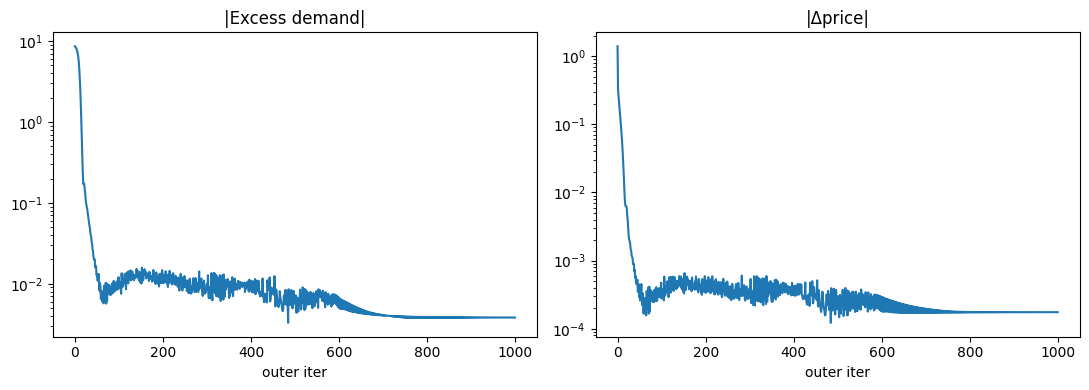


Final prices p (S, I):
[[1.2478 1.2027]
 [1.2436 1.2827]]
Final wages w  : [0.6861 0.6747]
Final rents r  : [0.0825 0.0882]
Final beta     : 1e-08
Final gamma    : [0.0133 0.0179]
Final I_infra  : [1. 1.]
Final Q_ship   :
[[[0.     0.    ]
  [0.2178 0.    ]]

 [[0.     0.1383]
  [0.     0.    ]]]
Final q_pop    :
[[[0.3377 0.1673]
  [0.1656 0.3362]]

 [[0.3341 0.1674]
  [0.1635 0.3282]]]

Final excess demand:
  goods: [[ 0.0029 -0.0001]
 [-0.0001  0.0018]]
  time : [-0.0001 -0.0001]
  land : [-0.0002 -0.0002]
  infra: 0.0


In [364]:
hist_ed  = solver.logger.history['excess_demand']
hist_dp  = solver.logger.history['price_changes']

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].semilogy(hist_ed);  ax[0].set_title('|Excess demand|'); ax[0].set_xlabel('outer iter')
ax[1].semilogy(hist_dp);  ax[1].set_title('|Δprice|');         ax[1].set_xlabel('outer iter')
plt.tight_layout(); plt.show()

print("\nFinal prices p (S, I):"); print(final_state.p)
print("Final wages w  :", final_state.w)
print("Final rents r  :", final_state.r)
print("Final beta     :", final_state.beta)
print("Final gamma    :", final_state.gamma)
print("Final I_infra  :", final_state.I_infra)
print("Final Q_ship   :"); print(final_state.Q_ship)
print("Final q_pop    :"); print(final_state.q_pop)
print("\nFinal excess demand:")
print("  goods:", ed.ED_goods)
print("  time :", ed.ED_time)
print("  land :", ed.ED_land)
print("  infra:", ed.ED_infra)